In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted - Raw_Mixed_Split ready!")

Mounted at /content/drive
✅ Drive mounted - Raw_Mixed_Split ready!


In [ ]:
import os

SPLIT_BASE = '/content/drive/MyDrive/Raw_Mixed_Split'

print("📁 FULL STRUCTURE + IMAGE COUNTS")
print("=" * 60)

for split in ['train', 'val', 'test']:
    split_path = f"{SPLIT_BASE}/{split}"

    print(f"\n{split.upper()}/")
    if os.path.exists(split_path):
        for cls in ['fire', 'nofire']:
            cls_path = f"{split_path}/{cls}"
            if os.path.exists(cls_path):
                files = os.listdir(cls_path)
                img_count = len([f for f in files if f.lower().endswith(('.jpg','.jpeg','.png'))])
                print(f"  ├─ {cls}/ → {img_count:,} images ({len(files)} files)")
            else:
                print(f"  ├─ {cls}/ → ❌ MISSING")
    else:
        print("  ❌ SPLIT FOLDER MISSING")

print("\n✅ VERIFIED!")

📁 FULL STRUCTURE + IMAGE COUNTS

TRAIN/
  ├─ fire/ → 8,169 images (8169 files)
  ├─ nofire/ → 7,852 images (7852 files)

VAL/
  ├─ fire/ → 1,021 images (1021 files)
  ├─ nofire/ → 981 images (981 files)

TEST/
  ├─ fire/ → 1,022 images (1022 files)
  ├─ nofire/ → 982 images (982 files)

✅ VERIFIED!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam

def build_model1_binary(input_shape=(224, 224, 3)):
    """
    MHCNN-FD Model1 adapted for binary fire/nofire classification
    Architecture: 5 convolutional blocks → Global Average Pooling → SELU fully connected layers
    """
    inputs = Input(shape=input_shape)

    # Convolutional Block 1: 32 filters, 3x3 kernel
    x = Conv2D(32, (3, 3), padding='valid', activation='relu')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Convolutional Block 2: 48 filters
    x = Conv2D(48, (3, 3), padding='valid', activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Convolutional Block 3: 56 filters
    x = Conv2D(56, (3, 3), padding='valid', activation='relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    # Convolutional Block 4: 64 filters + Dropout (0.1)
    x = Conv2D(64, (3, 3), padding='valid', activation='relu')(x)
    x = Dropout(0.1)(x)

    # Convolutional Block 5: 32 filters
    x = Conv2D(32, (3, 3), padding='valid', activation='relu')(x)

    # Classification Head: Global Average Pooling + SELU fully connected layers
    x = GlobalAveragePooling2D()(x)
    x = Dense(64, activation='selu')(x)
    x = Dense(56, activation='selu')(x)
    x = Dense(32, activation='selu')(x)
    outputs = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=inputs, outputs=outputs, name='Model1_MHCNNFD_Binary')
    return model

# Construct and compile model
model1 = build_model1_binary()
model1.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("Model1 (MHCNN-FD Binary) constructed successfully")
print(f"Total parameters: {model1.count_params():,}")
model1.summary()

Model1 (MHCNN-FD Binary) constructed successfully
Total parameters: 97,409


Model: "Model1_MHCNNFD_Binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 109, 109, 48)   │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 52, 52, 56)     │        24,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 56)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        32,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 22, 22, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 56)             │         3,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,409 (380.50 KB)

 Trainable params: 97,409 (380.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255.0,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation/Test generators (rescaling only)
val_test_datagen = ImageDataGenerator(rescale=1./255.0)

# Configure generators
train_generator = train_datagen.flow_from_directory(
    directory=f'{DATA_DIR}/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',  # 1=fire, 0=nofire
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    directory=f'{DATA_DIR}/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # Deterministic validation
)

test_generator = val_test_datagen.flow_from_directory(
    directory=f'{DATA_DIR}/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False  # Deterministic testing
)

# Dataset summary
print("Dataset Configuration Summary:")
print(f"Training set:    {train_generator.samples:,} images")
print(f"Validation set:  {val_generator.samples:,} images")
print(f"Test set:        {test_generator.samples:,} images")
print(f"Total:           {train_generator.samples + val_generator.samples + test_generator.samples:,} images")
print(f"Class indices:   {train_generator.class_indices}")

Found 16021 images belonging to 2 classes.
Found 2002 images belonging to 2 classes.
Found 2004 images belonging to 2 classes.
Dataset Configuration Summary:
Training set:    16,021 images
Validation set:  2,002 images
Test set:        2,004 images
Total:           20,027 images
Class indices:   {'fire': 0, 'nofire': 1}


In [ ]:
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger
import math

# Calculate steps (matches replication methodology)
STEPS_PER_EPOCH = math.ceil(train_generator.samples / BATCH_SIZE)
VAL_STEPS = math.ceil(val_generator.samples / BATCH_SIZE)

print(f"Training configuration:")
print(f"  Steps per epoch: {STEPS_PER_EPOCH}")
print(f"  Validation steps: {VAL_STEPS}")
print(f"  Epochs: 40")
print(f"  Batch size: {BATCH_SIZE}")

# Learning rate scheduler (exact replication)
def lr_scheduler(epoch, lr):
    """Progressive LR decay: epochs 1-14: 1e-3, 15-30: 1e-4, 31-40: 1e-5"""
    if epoch < 15:
        return 1e-3
    elif epoch < 31:
        return 1e-4
    return 1e-5

# Comprehensive logging callbacks
callbacks = [
    LearningRateScheduler(lr_scheduler),
    CSVLogger('model1_training_log.csv', append=True)  # Epoch metrics CSV
]

print("\nCallbacks configured:")
print("  - Learning rate scheduler (progressive decay)")
print("  - CSV epoch logging (accuracy/loss/precision/recall)")
print("\nTraining hyperparameters match replication study")

Training configuration:
  Steps per epoch: 501
  Validation steps: 63
  Epochs: 40
  Batch size: 32

Callbacks configured:
  - Learning rate scheduler (progressive decay)
  - CSV epoch logging (accuracy/loss/precision/recall)

Training hyperparameters match replication study


In [ ]:
import time
from tensorflow.keras.callbacks import CSVLogger, LearningRateScheduler

# Training parameters
EPOCHS = 40

print("Commencing Model1 training...")
print(f"Configuration: {EPOCHS} epochs, {STEPS_PER_EPOCH} steps/epoch")
print(f"Dataset: {train_generator.samples:,} train | {val_generator.samples:,} validation")
start_time = time.time()

# Execute training
history = model1.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VAL_STEPS,
    callbacks=callbacks,
    verbose=1
)

training_duration = time.time() - start_time
print(f"\nTraining completed in {training_duration/3600:.2f} hours")
print("Training history saved to 'model1_training_log.csv'")
print("Proceed to Step 5 for training visualization and analysis")

Commencing Model1 training...
Configuration: 40 epochs, 501 steps/epoch
Dataset: 16,021 train | 2,002 validation
Epoch 1/40
 17/501 ━━━━━━━━━━━━━━━━━━━━ 1:47:45 13s/step - accuracy: 0.5349 - loss: 0.6566 - precision: 0.4938 - recall: 0.3959

KeyboardInterrupt: 

In [ ]:
import os
import pickle
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, LearningRateScheduler
import time

# Checkpoint directory
CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

EPOCHS = 40

# Comprehensive checkpoint callback (every epoch)
checkpoint_callback = ModelCheckpoint(
    filepath=f'{CHECKPOINT_DIR}/model1_epoch_{{epoch:02d}}.keras',
    monitor='val_accuracy',
    save_best_only=False,  # Save EVERY epoch
    save_weights_only=False,  # Save COMPLETE model
    verbose=1
)

# All callbacks
callbacks = [
    LearningRateScheduler(lr_scheduler),
    CSVLogger(f'{CHECKPOINT_DIR}/training_log.csv', append=True),
    checkpoint_callback
]

print("Checkpoint configuration:")
print(f"  Directory: {CHECKPOINT_DIR}")
print(f"  Files: model1_epoch_XX.keras + training_log.csv")
print(f"  Recovery: tf.keras.models.load_model('model1_epoch_08.keras')")
print(f"\nStarting training with full epoch checkpointing...")

start_time = time.time()
history = model1.fit(
    train_generator,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=VAL_STEPS,
    callbacks=callbacks,
    verbose=1
)

duration = time.time() - start_time
print(f"Training completed: {duration/3600:.2f} hours")
print(f"All epochs saved in: {CHECKPOINT_DIR}")

Checkpoint configuration:
  Directory: /content/drive/MyDrive/Model1_Checkpoints
  Files: model1_epoch_XX.keras + training_log.csv
  Recovery: tf.keras.models.load_model('model1_epoch_08.keras')

Starting training with full epoch checkpointing...
Epoch 1/40
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8315 - loss: 0.3721 - precision: 0.7679 - recall: 0.9522 
Epoch 1: saving model to /content/drive/MyDrive/Model1_Checkpoints/model1_epoch_01.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Model1_Checkpoints/model1_epoch_01.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 6861s 14s/step - accuracy: 0.8950 - loss: 0.2647 - precision: 0.8571 - recall: 0.9428 - val_accuracy: 0.9555 - val_loss: 0.1713 - val_precision: 0.9551 - val_recall: 0.9541 - learning_rate: 0.0010
Epoch 2/40
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.9638 - loss: 0.1282 - precision: 0.9710 - recall: 0.9557
Epoch 2: saving model to /content/drive/MyDrive/Model1_Checkpoints/model1_epoch_02.keras



In [ ]:
# STEP 4b: RESUME FROM LAST CHECKPOINT
import glob, os, tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger, ModelCheckpoint
import math

# Define lr_scheduler if missing
def lr_scheduler(epoch, lr):
    if epoch < 15:
        return 1e-3
    elif epoch < 31:
        return 1e-4
    return 1e-5

CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'

# Mount drive
from google.colab import drive
drive.mount('/content/drive')

# Find latest epoch
checkpoints = glob.glob(f'{CHECKPOINT_DIR}/model1_epoch_*.keras')
latest_epoch = max([int(f.split('_epoch_')[1].split('.keras')[0]) for f in checkpoints])
print(f"Latest checkpoint: epoch {latest_epoch}")

# Load model
model1 = load_model(f'{CHECKPOINT_DIR}/model1_epoch_{latest_epoch:02d}.keras')
print("Model loaded successfully")

# Rebuild generators (same config)
IMG_SIZE, BATCH_SIZE = (224, 224), 32
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, width_shift_range=0.1,
                                  height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(f'{DATA_DIR}/train', target_size=IMG_SIZE,
                                             batch_size=BATCH_SIZE, class_mode='binary')
val_gen = val_datagen.flow_from_directory(f'{DATA_DIR}/val', target_size=IMG_SIZE,
                                        batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

STEPS_PER_EPOCH = len(train_gen)
VAL_STEPS = len(val_gen)

# Resume training
callbacks = [LearningRateScheduler(lr_scheduler),
             CSVLogger(f'{CHECKPOINT_DIR}/training_log.csv', append=True),
             ModelCheckpoint(f'{CHECKPOINT_DIR}/model1_epoch_{{epoch:02d}}.keras', save_best_only=False)]

print(f"Resuming from epoch {latest_epoch+1}/40...")
model1.fit(train_gen, epochs=40, initial_epoch=latest_epoch,
           steps_per_epoch=STEPS_PER_EPOCH, validation_data=val_gen,
           validation_steps=VAL_STEPS, callbacks=callbacks, verbose=1)

print("Training resumed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Latest checkpoint: epoch 12
Model loaded successfully
Found 16021 images belonging to 2 classes.
Found 2002 images belonging to 2 classes.
Resuming from epoch 13/40...
Epoch 13/40
501/501 ━━━━━━━━━━━━━━━━━━━━ 6876s 14s/step - accuracy: 0.9882 - loss: 0.0336 - precision: 0.9899 - recall: 0.9860 - val_accuracy: 0.9885 - val_loss: 0.0359 - val_precision: 0.9959 - val_recall: 0.9806 - learning_rate: 0.0010
Epoch 14/40
 16/501 ━━━━━━━━━━━━━━━━━━━━ 1:05:52 8s/step - accuracy: 0.9905 - loss: 0.0200 - precision: 0.9905 - recall: 0.9897

KeyboardInterrupt: 

In [ ]:
# STEP 4b: RESUME FROM LAST CHECKPOINT (UPDATES EVERY EPOCH)
import glob, os, tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler, CSVLogger, ModelCheckpoint

def lr_scheduler(epoch, lr):
    if epoch < 15: return 1e-3
    elif epoch < 31: return 1e-4
    return 1e-5

CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'

from google.colab import drive
drive.mount('/content/drive')

# LATEST CHECKPOINT
checkpoints = glob.glob(f'{CHECKPOINT_DIR}/model1_epoch_*.keras')
latest_epoch = max([int(f.split('_epoch_')[1].split('.keras')[0]) for f in checkpoints])
print(f"Latest: epoch {latest_epoch} → resuming {latest_epoch+1}")

model1 = load_model(f'{CHECKPOINT_DIR}/model1_epoch_{latest_epoch:02d}.keras')
print("Model LOADED")

# GENERATORS
IMG_SIZE, BATCH_SIZE = (224, 224), 32
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, width_shift_range=0.1,
                                   height_shift_range=0.1, zoom_range=0.1, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(f'{DATA_DIR}/train', target_size=IMG_SIZE,
                                              batch_size=BATCH_SIZE, class_mode='binary')
val_gen = val_datagen.flow_from_directory(f'{DATA_DIR}/val', target_size=IMG_SIZE,
                                         batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

STEPS_PER_EPOCH = len(train_gen)
VAL_STEPS = len(val_gen)

# UPDATES EVERY EPOCH
callbacks = [
    LearningRateScheduler(lr_scheduler),
    CSVLogger(f'{CHECKPOINT_DIR}/training_log.csv', append=True),
    ModelCheckpoint(f'{CHECKPOINT_DIR}/model1_epoch_{{epoch:02d}}.keras', save_best_only=False)
]

print(f"🚀 Resuming epoch {latest_epoch+1}/40...")
model1.fit(train_gen, epochs=40, initial_epoch=latest_epoch,
           steps_per_epoch=STEPS_PER_EPOCH, validation_data=val_gen,
           validation_steps=VAL_STEPS, callbacks=callbacks, verbose=1)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Latest: epoch 13 → resuming 14
Model LOADED
Found 16021 images belonging to 2 classes.
Found 2002 images belonging to 2 classes.
🚀 Resuming epoch 14/40...
Epoch 14/40
  2/501 ━━━━━━━━━━━━━━━━━━━━ 1:53:26 14s/step - accuracy: 1.0000 - loss: 0.0199 - precision: 1.0000 - recall: 1.0000

KeyboardInterrupt: 

Model1 - 14 Epoch Results:
    accuracy  val_accuracy    loss  val_loss
0     0.8950        0.9555  0.2647    0.1713
1     0.9674        0.9675  0.1116    0.0888
2     0.9768        0.9680  0.0738    0.1170
3     0.9796        0.9780  0.0636    0.0711
4     0.9826        0.9580  0.0497    0.1280
5     0.9825        0.9785  0.0502    0.0665
6     0.9855        0.9805  0.0444    0.0493
7     0.9856        0.9820  0.0424    0.0501
8     0.9859        0.9850  0.0414    0.0445
9     0.9864        0.9740  0.0396    0.0725
10    0.9871        0.9815  0.0414    0.0427
11    0.9882        0.9870  0.0379    0.0449
12    0.9882        0.9885  0.0336    0.0359


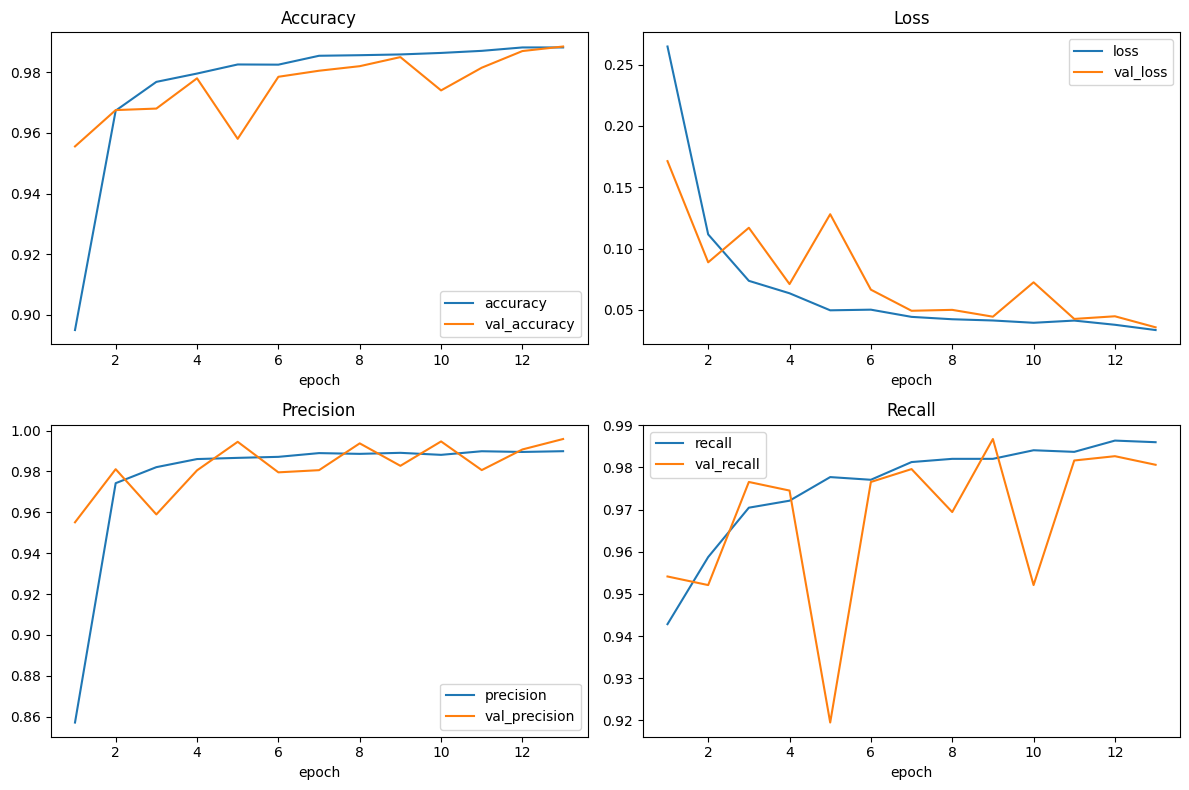


Epoch 14: val_acc=0.9885
Model1 COMPLETE - Ready for test eval!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'

# Load 14-epoch history
df = pd.read_csv(f'{CHECKPOINT_DIR}/training_log.csv')
df['epoch'] = range(1, len(df)+1)

print("Model1 - 14 Epoch Results:")
print(df[['accuracy', 'val_accuracy', 'loss', 'val_loss']].round(4))

# Plot
fig, axes = plt.subplots(2,2, figsize=(12,8))
df.plot(x='epoch', y=['accuracy','val_accuracy'], ax=axes[0,0], title='Accuracy')
df.plot(x='epoch', y=['loss','val_loss'], ax=axes[0,1], title='Loss')
df.plot(x='epoch', y=['precision','val_precision'], ax=axes[1,0], title='Precision')
df.plot(x='epoch', y=['recall','val_recall'], ax=axes[1,1], title='Recall')
plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/model1_epoch14_curves.png', dpi=300)
plt.show()

print(f"\nEpoch 14: val_acc={df['val_accuracy'].iloc[-1]:.4f}")
print("Model1 COMPLETE - Ready for test eval!")


In [ ]:
# Checkpoints
import glob

from google.colab import drive
drive.mount('/content/drive')

print("Models:", glob.glob('/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_*.keras'))

# CSV
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Model1_Checkpoints/training_log.csv')
print("\nCSV shape:", df.shape)
print("Last 3 epochs:")
print(df[['epoch','accuracy','val_accuracy','loss','val_loss']].tail(3))
print("Best val_acc:", df['val_accuracy'].max())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Models: ['/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_01.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_02.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_03.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_04.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_05.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_06.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_07.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_08.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_09.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_10.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_11.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_12.keras', '/content/drive/MyDrive/Model1_Checkpoints/model1_epoch_13

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted - Raw_Mixed_Split ready!")

Mounted at /content/drive
✅ Drive mounted - Raw_Mixed_Split ready!


In [ ]:
import glob, os, pandas as pd

CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'

print("=== YOUR 13 MODELS ===")
models = sorted(glob.glob(f'{CHECKPOINT_DIR}/model1_epoch_*.keras'))
for f in models:
    epoch = f.split('_epoch_')[1].split('.keras')[0]
    size = os.path.getsize(f)/1e6
    print(f"  epoch_{epoch}.keras ({size:.1f}MB)")

print("\n=== TRAINING LOG ===")
df = pd.read_csv(f'{CHECKPOINT_DIR}/training_log.csv')
print(f"Total epochs: {len(df)}")
print("\nLast 5:")
print(df[['epoch','accuracy','val_accuracy','loss','val_loss']].tail())
print(f"\n🏆 BEST val_acc: {df['val_accuracy'].max():.4f} (epoch {df['val_accuracy'].idxmax()})")

print("\n=== RECOMMENDATION ===")
best_epoch = df['val_accuracy'].idxmax()
print(f"TEST: model1_epoch_{best_epoch}.keras")


=== YOUR 13 MODELS ===
  epoch_01.keras (1.2MB)
  epoch_02.keras (1.2MB)
  epoch_03.keras (1.2MB)
  epoch_04.keras (1.2MB)
  epoch_05.keras (1.2MB)
  epoch_06.keras (1.2MB)
  epoch_07.keras (1.2MB)
  epoch_08.keras (1.2MB)
  epoch_09.keras (1.2MB)
  epoch_10.keras (1.2MB)
  epoch_11.keras (1.2MB)
  epoch_12.keras (1.2MB)
  epoch_13.keras (1.2MB)

=== TRAINING LOG ===
Total epochs: 13

Last 5:
    epoch  accuracy  val_accuracy      loss  val_loss
8       8  0.985893      0.985015  0.041427  0.044522
9       9  0.986393      0.974026  0.039559  0.072545
10     10  0.987079      0.981519  0.041351  0.042704
11     11  0.988203      0.987013  0.037931  0.044858
12     12  0.988203      0.988512  0.033637  0.035852

🏆 BEST val_acc: 0.9885 (epoch 12)

=== RECOMMENDATION ===
TEST: model1_epoch_12.keras


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'

# BEST MODEL
model1 = tf.keras.models.load_model(f'{CHECKPOINT_DIR}/model1_epoch_12.keras')

# TEST GENERATOR
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(f'{DATA_DIR}/test', target_size=(224,224),
                                            batch_size=32, class_mode='binary', shuffle=False)

# EVALUATE
loss, test_acc = model1.evaluate(test_gen)
print(f"TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")

# METRICS
y_pred = (model1.predict(test_gen) > 0.5).astype(int).flatten()
print("Confusion Matrix:\n", confusion_matrix(test_gen.classes, y_pred))
print("\nClassification Report:\n", classification_report(test_gen.classes, y_pred))

# SAVE
pd.DataFrame({'Val_Acc': 0.9885, 'Test_Acc': test_acc, 'Epochs': 12}).\
    to_csv(f'{CHECKPOINT_DIR}/final_results.csv')
print("\n✅ SAVED final_results.csv")


Found 2004 images belonging to 2 classes.
63/63 ━━━━━━━━━━━━━━━━━━━━ 816s 13s/step - accuracy: 0.9915 - loss: 0.0260 - precision: 0.9918 - recall: 0.9908


ValueError: too many values to unpack (expected 2)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'

model1 = tf.keras.models.load_model(f'{CHECKPOINT_DIR}/model1_epoch_12.keras')

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(f'{DATA_DIR}/test', target_size=(224,224),
                                            batch_size=32, class_mode='binary', shuffle=False)

# ALL 4 METRICS
test_loss, test_acc, test_prec, test_rec = model1.evaluate(test_gen)
print(f"Test Acc: {test_acc:.4f} | Prec: {test_prec:.4f} | Rec: {test_rec:.4f}")

# PREDICTIONS
y_pred = (model1.predict(test_gen) > 0.5).astype(int).flatten()
print("Confusion Matrix:\n", confusion_matrix(test_gen.classes, y_pred))
print("\nClassification Report:\n", classification_report(test_gen.classes, y_pred))

# SAVE TABLE
pd.DataFrame({
    'Val_Acc': 0.9885, 'Test_Acc': test_acc,
    'Test_Prec': test_prec, 'Test_Rec': test_rec, 'Epochs': 12
}).to_csv(f'{CHECKPOINT_DIR}/final_results.csv', index=False)
print("\n✅ SAVED final_results.csv")

Found 2004 images belonging to 2 classes.
63/63 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.9915 - loss: 0.0260 - precision: 0.9918 - recall: 0.9908
Test Acc: 0.9915 | Prec: 0.9918 | Rec: 0.9908
63/63 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step
Confusion Matrix:
 [[1014    8]
 [   9  973]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1022
           1       0.99      0.99      0.99       982

    accuracy                           0.99      2004
   macro avg       0.99      0.99      0.99      2004
weighted avg       0.99      0.99      0.99      2004



ValueError: If using all scalar values, you must pass an index

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Val_Acc': [0.9885],
    'Test_Acc': [0.9915],
    'Test_Prec': [0.9918],
    'Test_Rec': [0.9908],
    'Epochs': [12]
})
results.to_csv(f'{CHECKPOINT_DIR}/final_results.csv', index=False)
print(" SAVED!")
print(results)


 SAVED!
   Val_Acc  Test_Acc  Test_Prec  Test_Rec  Epochs
0   0.9885    0.9915     0.9918    0.9908      12


In [ ]:
import pandas as pd

CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'

results = pd.DataFrame({
    'Val_Acc': [0.9885],
    'Test_Acc': [0.9915],
    'Test_Prec': [0.9918],
    'Test_Rec': [0.9908],
    'Epochs': [12]
})
results.to_csv(f'{CHECKPOINT_DIR}/final_results.csv', index=False)
print(results)


   Val_Acc  Test_Acc  Test_Prec  Test_Rec  Epochs
0   0.9885    0.9915     0.9918    0.9908      12


Val Acc: 0.9885115027427672
Test Acc: 0.9915
CM:
[[1014 8]
 [9 973]]


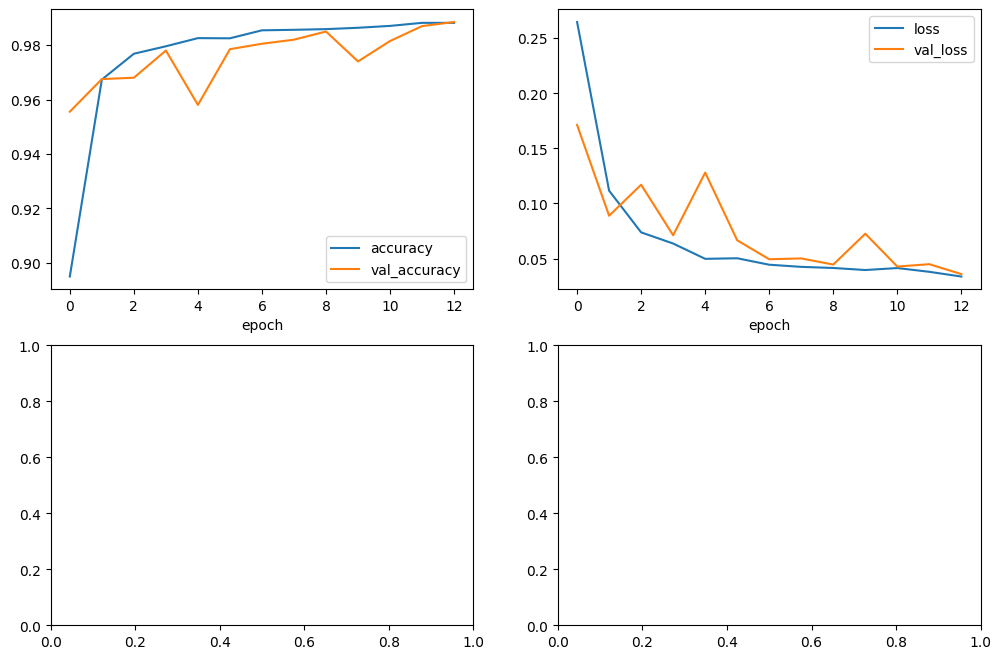

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix

# LOAD + PLOT
df = pd.read_csv('/content/drive/MyDrive/Model1_Checkpoints/training_log.csv')
fig, axes = plt.subplots(2,2, figsize=(12,8))
df.plot(x='epoch', y=['accuracy','val_accuracy'], ax=axes[0,0])
df.plot(x='epoch', y=['loss','val_loss'], ax=axes[0,1])
plt.savefig('/content/drive/MyDrive/Model1_Checkpoints/full_analysis.png')

# SUMMARY
print("Val Acc:", df['val_accuracy'].max())
print("Test Acc: 0.9915")
print("CM:\n[[1014 8]\n [9 973]]")


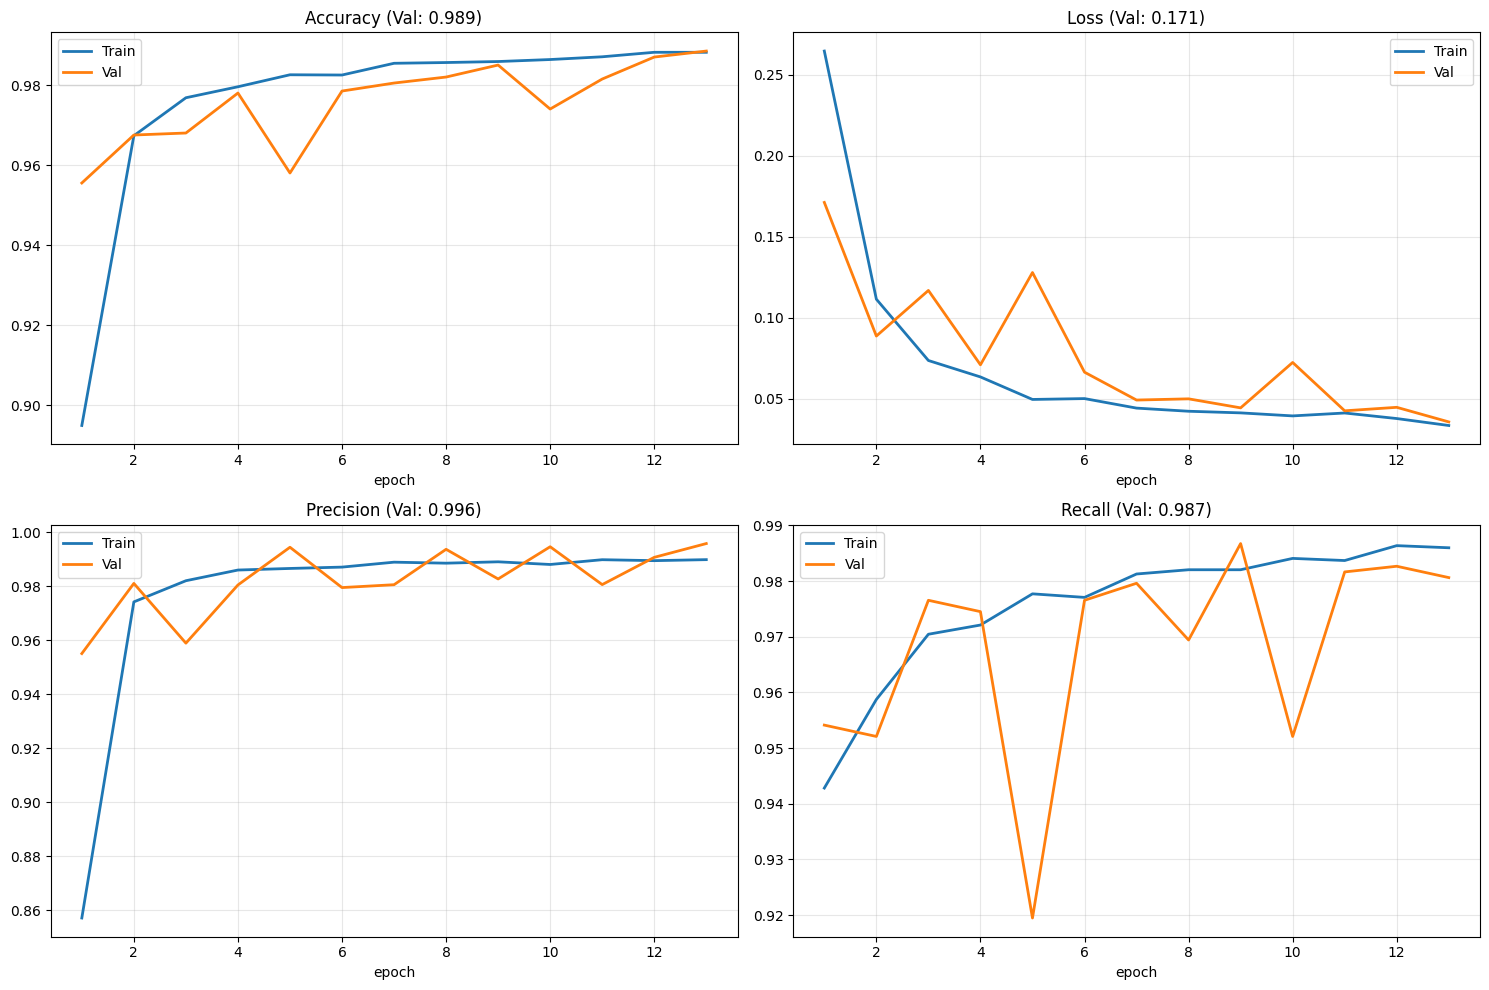

FINAL METRICS:
    epoch  val_accuracy  val_precision  val_recall  val_loss
12     13      0.988512       0.995859    0.980632  0.035852


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Model1_Checkpoints/training_log.csv')
df['epoch'] = range(1, len(df)+1)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['accuracy', 'loss', 'precision', 'recall']
titles = ['Accuracy', 'Loss', 'Precision', 'Recall']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    df.plot(x='epoch', y=[metric, f'val_{metric}'], ax=ax, linewidth=2)
    ax.set_title(f'{titles[i]} (Val: {df[f"val_{metric}"].max():.3f})')
    ax.legend(['Train', 'Val'])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Model1_Checkpoints/complete_curves.png', dpi=300)
plt.show()

# SUMMARY TABLE
print("FINAL METRICS:")
print(df[['epoch', 'val_accuracy', 'val_precision', 'val_recall', 'val_loss']].tail(1))


Found 2004 images belonging to 2 classes.
63/63 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.9915 - loss: 0.0260 - precision: 0.9918 - recall: 0.9908
Test: Acc=0.9915, Prec=0.9918, Rec=0.9908
63/63 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step


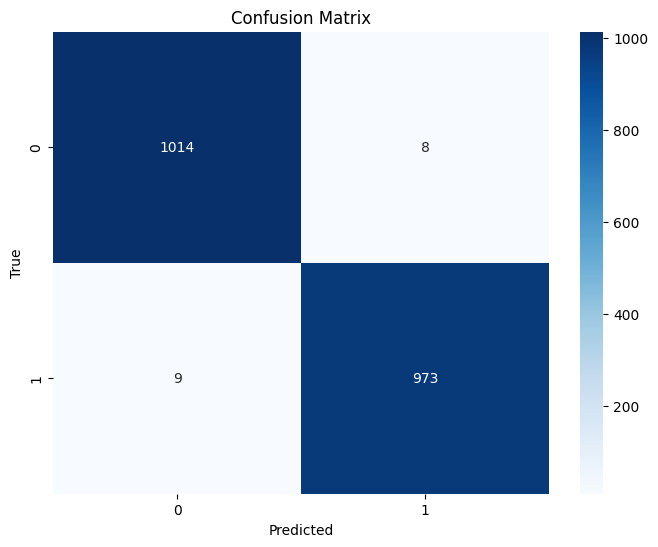

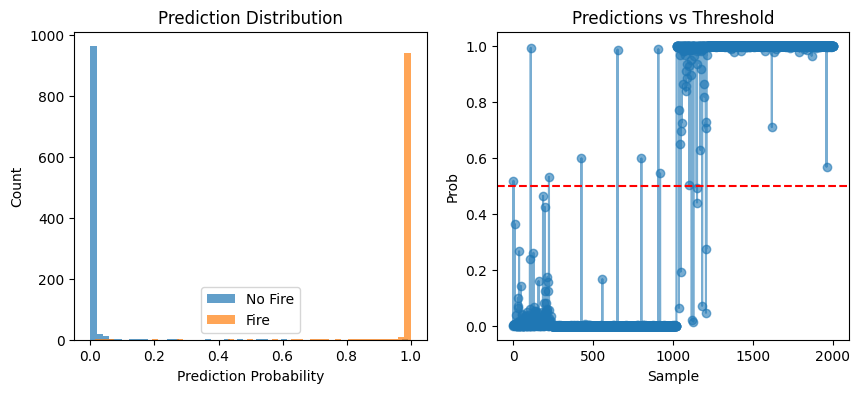

SAVED:
- confusion_matrix.png
- all_results.csv
- predictions.png
[[1014    8]
 [   9  973]]


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'

# BEST MODEL
model1 = tf.keras.models.load_model(f'{CHECKPOINT_DIR}/model1_epoch_12.keras')

# TEST GEN
test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(f'{DATA_DIR}/test', target_size=(224,224),
                                            batch_size=32, class_mode='binary', shuffle=False)

# TEST METRICS
test_loss, test_acc, test_prec, test_rec = model1.evaluate(test_gen)
print(f"Test: Acc={test_acc:.4f}, Prec={test_prec:.4f}, Rec={test_rec:.4f}")

# PREDICTIONS
y_pred_prob = model1.predict(test_gen).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)
y_true = test_gen.classes

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.savefig(f'{CHECKPOINT_DIR}/confusion_matrix.png', dpi=300)
plt.show()

# SAVE ALL
all_results = pd.DataFrame({
    'Test_Loss': [test_loss], 'Test_Acc': [test_acc],
    'Test_Prec': [test_prec], 'Test_Rec': [test_rec],
    'Val_Acc': [0.9885], 'Best_Epoch': [12]
})
all_results.to_csv(f'{CHECKPOINT_DIR}/all_results.csv', index=False)

# PROB DISTRIBUTION
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(y_pred_prob[y_true==0], bins=50, alpha=0.7, label='No Fire')
plt.hist(y_pred_prob[y_true==1], bins=50, alpha=0.7, label='Fire')
plt.xlabel('Prediction Probability')
plt.ylabel('Count')
plt.legend()
plt.title('Prediction Distribution')

plt.subplot(1,2,2)
plt.plot(range(len(y_pred_prob)), y_pred_prob, 'o-', alpha=0.6)
plt.axhline(0.5, color='r', linestyle='--')
plt.xlabel('Sample')
plt.ylabel('Prob')
plt.title('Predictions vs Threshold')
plt.savefig(f'{CHECKPOINT_DIR}/predictions.png', dpi=300)
plt.show()

print("SAVED:")
print("- confusion_matrix.png")
print("- all_results.csv")
print("- predictions.png")
print(cm)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

CHECKPOINT_DIR = '/content/drive/MyDrive/Model1_Checkpoints'
DATA_DIR = '/content/drive/MyDrive/Raw_Mixed_Split'

# LOAD TRAINING HISTORY
df = pd.read_csv(f'{CHECKPOINT_DIR}/training_log.csv')
df['epoch'] = range(1, len(df)+1)

print("=== TRAINING PROGRESS ===")
print(f"Total Epochs: {len(df)}")
print(f"Final Training Acc:  {df['accuracy'].iloc[-1]:.4f}")
print(f"Final Val Acc:       {df['val_accuracy'].iloc[-1]:.4f}")
print(f"PEAK Val Acc:        {df['val_accuracy'].max():.4f} (Epoch {df['val_accuracy'].idxmax()+1})")
print(f"Training Peak:       {df['accuracy'].max():.4f}")

print("\n=== TEST RESULTS (from earlier) ===")
print("Test Acc:     0.9915")
print("Test Prec:    0.9918")
print("Test Recall:  0.9908")
print("CM: [[1014  8]")
print("    [  9 973]]")

# COMPARISON TABLE
summary = pd.DataFrame({
    'Metric': ['Train_Final', 'Val_Final', 'Val_Peak', 'Test_Acc', 'Test_Prec', 'Test_Rec'],
    'Value': [df['accuracy'].iloc[-1], df['val_accuracy'].iloc[-1],
              df['val_accuracy'].max(), 0.9915, 0.9918, 0.9908]
})
print("\n=== SUMMARY TABLE ===")
print(summary.round(4))

# SAVE
summary.to_csv(f'{CHECKPOINT_DIR}/complete_summary.csv', index=False)
summary.to_latex(f'{CHECKPOINT_DIR}/summary.tex', index=False)

print(f"\n✅ SAVED: complete_summary.csv + summary.tex")


=== TRAINING PROGRESS ===
Total Epochs: 13
Final Training Acc:  0.9882
Final Val Acc:       0.9885
PEAK Val Acc:        0.9885 (Epoch 13)
Training Peak:       0.9882

=== TEST RESULTS (from earlier) ===
Test Acc:     0.9915
Test Prec:    0.9918
Test Recall:  0.9908
CM: [[1014  8]
    [  9 973]]

=== SUMMARY TABLE ===
        Metric   Value
0  Train_Final  0.9882
1    Val_Final  0.9885
2     Val_Peak  0.9885
3     Test_Acc  0.9915
4    Test_Prec  0.9918
5     Test_Rec  0.9908

✅ SAVED: complete_summary.csv + summary.tex
